# EPOCH 5th Datathon 본선 — Team3 빡빡이 최종 코드

**리더보드 PR-AUC 0.7523**

| 단계 | 내용 |
|---|---|
| 0. EDA | 정답 구조 · 분포 이동 · 결측 확인 |
| 1. 순위 블렌드 | 팀 모델(BEST_v2) 0.7 + T01 0.2 + q_joint 0.1 |
| 2. 중도절단 규칙 | 08-25 정답 1 + 08-25\~08-31 롱폼 0편인 9개 채널을 1\~9위로 |
| 3. 저장 | 694행, 0\~1 범위 점검 |
| 부록 | q_joint · 구조 시뮬레이션 학습 코드 |

**실행:** `./epoch_data/`에 대회 데이터를 두고 위에서부터 실행. 랜덤 요소 없음.

In [ ]:
import os, numpy as np, pandas as pd
DATA = './epoch_data'                                   # 대회 데이터 폴더
MATE, T01, QJ = 'mate.csv', 'blends/T01_ranklearn50_S01x50.csv', 'submit_qjoint.csv'   # (선택) 모델 출력 파일
D_TEST, D_PREV = '2026-09-01', '2026-08-25'             # 테스트 기준일, 직전 공식 정답일
def clean(df):
    df.columns = [c.strip().lstrip('\ufeff') for c in df.columns]; return df
ss = clean(pd.read_csv(os.path.join(DATA, 'sample_submission.csv')))
order = ss.row_id.astype(str).tolist()
print('rows', len(order))

rows 694


## 0. 데이터 탐색 (EDA)
제출 결과와 무관한 분석 셀이다(변수 이름 앞에 `e`/`eda_`를 붙여 아래 단계와 분리).

In [ ]:
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from matplotlib import font_manager
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
for f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Noto Sans CJK JP']:   # 한글 폰트
    if any(f == x.name for x in font_manager.fontManager.ttflist): plt.rcParams['font.family'] = f; break
plt.rcParams['axes.unicode_minus'] = False
GREEN, GOLD, GREY, INK, LIGHT, MID = '#37654A', '#C28B2C', '#8A8F8B', '#262626', '#D9E2DC', '#A9BFB0'
def style(ax):
    ax.spines[['top', 'right']].set_visible(False); ax.spines[['left', 'bottom']].set_color(LIGHT)
    ax.tick_params(colors=GREY); ax.grid(axis='y', color='#EEF1EE'); ax.set_axisbelow(True)

ev = clean(pd.read_csv(os.path.join(DATA, 'video_5d_views.csv')))
ev['published_at'] = pd.to_datetime(ev.published_at, utc=True).dt.tz_localize(None)
eL = ev[(ev.is_shorts == 0) & ev.view_5d.notna()].copy()     # 정답은 롱폼만으로 결정
eL['lv'] = np.log1p(eL.view_5d)

def eda_label(D, F):
    # 공식 정답 규칙: s = log1p(미래 F일 중앙값) - log1p(과거 중앙값), 그날 상위 20% = 1
    p = eL[eL.published_at < D].groupby('channel_id').view_5d.agg(['median', 'size'])
    p = p[(p['size'] >= 3) & (p['median'] >= 100)]['median']
    f = eL[(eL.published_at >= D) & (eL.published_at < D + pd.Timedelta(days=F))].groupby('channel_id').view_5d.median()
    s = np.log1p(f.reindex(p.index).fillna(0)) - np.log1p(p)
    return (s >= s.quantile(.8)).astype(int), s.quantile(.8)

### EDA ① 가장 강한 단서: 직전 정답

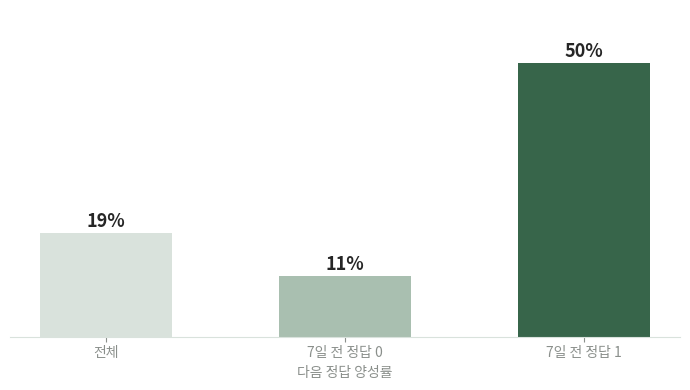

{'전체': '19.0%', '7일 전 정답 0': '11.1%', '7일 전 정답 1': '50.2%'}


In [ ]:
# 테스트와 같은 구조: 다음 정답(26일 창) vs 7일 전 정답(18일 창), 기준일 07-25 ~ 08-05
rows = []
for D in pd.date_range('2026-07-25', '2026-08-05'):
    P = D - pd.Timedelta(days=7)
    y, _ = eda_label(D, 26); prev, _ = eda_label(P, 18)
    n_obs = eL[(eL.published_at >= P) & (eL.published_at < D)].groupby('channel_id').size()
    r = pd.DataFrame({'y': y}).join(prev.rename('prev'), how='inner')
    r['n_obs'] = n_obs.reindex(r.index).fillna(0)
    rows.append(r)
R = pd.concat(rows)
rate = {'전체': R.y.mean(), '7일 전 정답 0': R[R.prev == 0].y.mean(), '7일 전 정답 1': R[R.prev == 1].y.mean()}
fig, ax = plt.subplots(figsize=(7, 4)); style(ax)
ax.bar(rate.keys(), rate.values(), color=[LIGHT, MID, GREEN], width=0.55)
for i, v in enumerate(rate.values()): ax.text(i, v + 0.012, f'{v:.0%}', ha='center', fontsize=13, fontweight='bold', color=INK)
ax.set_ylim(0, 0.6); ax.get_yaxis().set_visible(False); ax.spines['left'].set_visible(False)
ax.set_xlabel('다음 정답 양성률', color=GREY); plt.tight_layout(); plt.show()
print({k: f'{v:.1%}' for k, v in rate.items()})

### EDA ② 분포가 움직인다: 08-25\~27 플랫폼 전체 급등

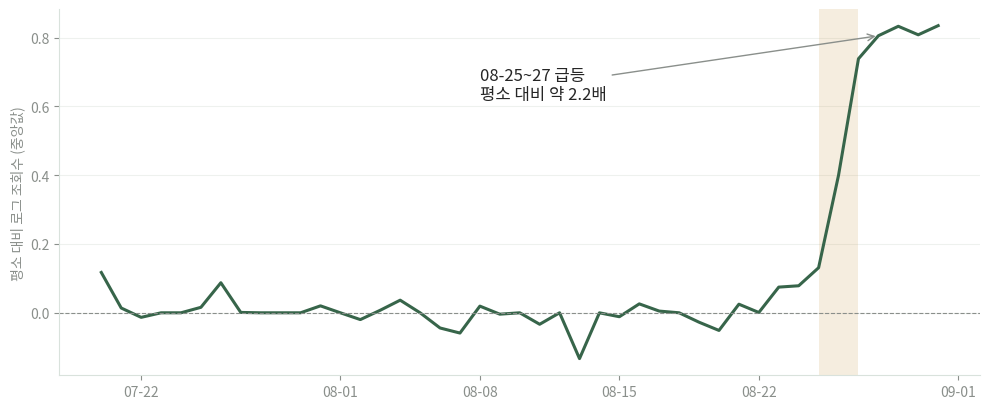

In [ ]:
# 업로드일별 '채널 평소(08-20 이전 중앙값) 대비' 로그 조회수의 중앙값
pre = eL[eL.published_at < '2026-08-20'].groupby('channel_id').lv.median()
rel = (eL.lv - eL.channel_id.map(pre)).dropna()
daily = rel.groupby(eL.loc[rel.index, 'published_at'].dt.normalize()).median().loc['2026-07-20':]
fig, ax = plt.subplots(figsize=(10, 4.2)); style(ax)
ax.plot(daily.index, daily.values, color=GREEN, lw=2.2)
ax.axvspan(pd.Timestamp('2026-08-25'), pd.Timestamp('2026-08-27'), color=GOLD, alpha=0.15, lw=0)
ax.axhline(0, color=GREY, lw=0.8, ls='--')
ax.annotate(f'08-25~27 급등\n평소 대비 약 {np.exp(daily.loc["2026-08-28"]):.1f}배', xy=(pd.Timestamp('2026-08-28'), daily.loc['2026-08-28']),
            xytext=(pd.Timestamp('2026-08-08'), 0.62), fontsize=12, color=INK, arrowprops=dict(arrowstyle='->', color=GREY))
ax.set_ylabel('평소 대비 로그 조회수 (중앙값)', color=GREY); ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.tight_layout(); plt.show()

### EDA ③ 분포가 움직인다: 상위 20% 문턱의 이동

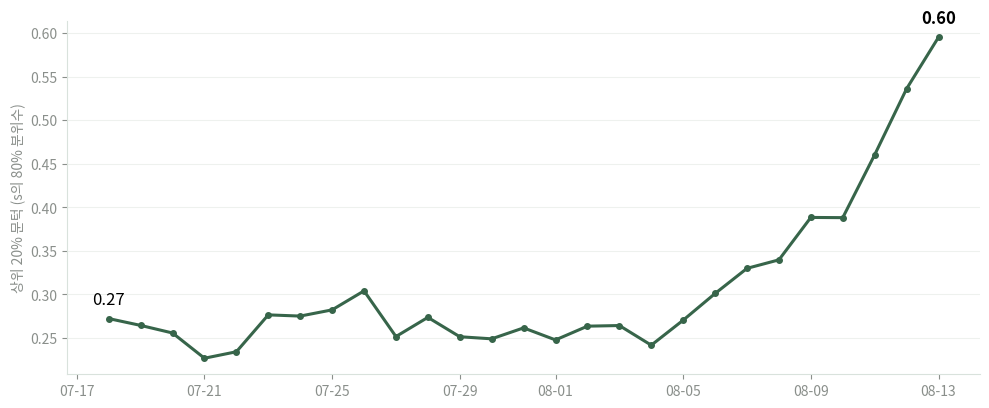

In [ ]:
# 기준일별 상위 20% 문턱(s의 80% 분위수), 18일 미래 창이 모두 관측되는 날짜만
T = pd.Series({D: eda_label(D, 18)[1] for D in pd.date_range('2026-07-18', '2026-08-13')})
fig, ax = plt.subplots(figsize=(10, 4.2)); style(ax)
ax.plot(T.index, T.values, color=GREEN, lw=2.2, marker='o', ms=4)
ax.annotate(f'{T.iloc[0]:.2f}', (T.index[0], T.iloc[0]), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=12)
ax.annotate(f'{T.iloc[-1]:.2f}', (T.index[-1], T.iloc[-1]), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('상위 20% 문턱 (s의 80% 분위수)', color=GREY); ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.tight_layout(); plt.show()

### EDA ④ 결측은 무작위가 아니다

In [ ]:
# 결측 여부를 다른 피처(날짜별 순위)로 예측한 AUC. 0.5보다 크면 무작위 결측이 아님
def eda_feats(D):
    pl = eL[eL.published_at < D].copy(); pl['age'] = (D - pl.published_at) / pd.Timedelta(days=1)
    g = pl.groupby('channel_id')
    f = pd.DataFrame({'past_med': g.lv.median(), 'past_std': g.lv.std(), 'past_n': g.size()})
    for w in (3, 7, 14):
        r = pl[pl.age <= w].groupby('channel_id').lv
        f[f'm{w}'] = r.median() - f.past_med; f[f'r{w}_n'] = r.size()
    f[['r7_n', 'r14_n']] = f[['r7_n', 'r14_n']].fillna(0)
    f['m14_old'] = pl[pl.age <= 14].groupby('channel_id').lv.median() - pl[pl.age > 14].groupby('channel_id').lv.median()
    f['days_since'] = g.age.min(); f['upl_rate'] = f.past_n / g.age.max().clip(lower=1)
    f['cv_last10'] = g.tail(10).groupby('channel_id').lv.std()
    return f[f.past_n >= 3].assign(D=D)
X = pd.concat([eda_feats(D) for D in pd.date_range('2026-07-25', '2026-08-31', freq='3D')])
base_cols = ['past_med', 'past_std', 'r7_n', 'r14_n', 'days_since', 'upl_rate', 'cv_last10']
Z = pd.concat({c: X.groupby('D')[c].rank(pct=True) for c in base_cols}, axis=1).fillna(0.5)
auc = {}
for c in ['m3', 'm7', 'm14_old']:
    y = X[c].isna().astype(int)
    auc[c] = roc_auc_score(y, LogisticRegression(max_iter=2000).fit(Z, y).predict_proba(Z)[:, 1])
for c, a in auc.items(): print(f'{c:8s} 결측 여부 예측 AUC = {a:.2f}  (무작위 결측이면 0.5)')

m3       결측 여부 예측 AUC = 0.99  (무작위 결측이면 0.5)
m7       결측 여부 예측 AUC = 1.00  (무작위 결측이면 0.5)
m14_old  결측 여부 예측 AUC = 0.73  (무작위 결측이면 0.5)


**EDA → 설계**

| 발견 | 설계 |
|---|---|
| 정답 = 그날 상위 20% (상대 기준) | 공식 정의로 매일 학습 라벨 재구성, 피처를 날짜별 순위로 변환 |
| 08-25\~27 급등, 문턱 이동 | 최근일 가중(반감기 7일), KFold 대신 시간 기반 검증 |
| 직전 정답이 가장 강한 단서, 단 08-31 이후 미관측 | 역추론 피처 `lag_x_obs`, 우측 중도절단 소프트 라벨, 최종 규칙 |
| 결측이 무작위가 아님 | 결측 지시변수 + MICE |

## 1. 순위 블렌드
PR-AUC는 순위만 평가하므로 각 모델 출력을 순위로 바꿔 가중합한다.
`score = Σ wᵢ · rank(모델ᵢ)` → `pred = 1 / (1 + exp(−8 · (rank(score) − 0.8)))` (순서 보존 변환)

In [ ]:
# 1단계 블렌드 결과(694행, sample_submission 순서) 내장 → 모델 출력 파일 없이도 재현
import io
BLEND_VALUES = '''
0.11597364 0.00179795 0.00358407 0.11835831 0.00949134 0.24379432 0.82712941 0.00535579
0.01734613 0.28521633 0.00272021 0.00171707 0.00284821 0.15188601 0.00856402 0.71969304
0.00256825 0.01139184 0.74234895 0.76377473 0.01942432 0.00573713 0.00175705 0.011923
0.80824035 0.00370972 0.04693359 0.10147156 0.00628788 0.00529473 0.01825282 0.02406603
0.34869422 0.00456123 0.00223721 0.01016413 0.31797091 0.008762 0.44774197 0.09143371
0.00275166 0.78000681 0.05530283 0.20382844 0.05651973 0.00183981 0.00342312 0.47782436
0.00234253 0.15040705 0.35131671 0.69829524 0.00190442 0.00204052 0.03680744 0.03933961
0.32299154 0.13899874 0.0701467 0.28170437 0.01856526 0.00799629 0.00216132 0.79729167
0.00323202 0.01794553 0.00201718 0.12576821 0.21141344 0.12450623 0.23539436 0.03763358
0.59341428 0.00927703 0.63970025 0.77199254 0.68849305 0.1928339 0.22719686 0.70071825
0.81002061 0.693416 0.1689505 0.71736168 0.03220552 0.64499671 0.00305155 0.00763871
0.01920597 0.01126275 0.44204835 0.00192646 0.19644778 0.27706287 0.31547629 0.0056071
0.81178819 0.07400055 0.06939853 0.11132938 0.28521633 0.00713188 0.15946048 0.08057336
0.00477544 0.09434745 0.0650626 0.71501862 0.02816214 0.02632971 0.8064474 0.01165443
0.22922718 0.00746591 0.42506441 0.51094926 0.24167543 0.00346267 0.42788393 0.83201839
0.0024528 0.68352713 0.20196414 0.32551733 0.00755182 0.1322433 0.62631179 0.13092607
0.01620573 0.00383975 0.45916894 0.6181833 0.15487974 0.01566351 0.00600623 0.00169742
0.04491363 0.00772659 0.01100888 0.01531199 0.75106919 0.01004881 0.02199257 0.00173694
0.00587015 0.76168861 0.79542226 0.5396858 0.65025787 0.00896452 0.67092947 0.00301668
0.12201484 0.09533704 0.01774351 0.23747542 0.01398195 0.00226308 0.62900576 0.00397432
0.0055432 0.80282334 0.00960033 0.01254984 0.14604119 0.57662497 0.37530838 0.58504431
0.00650769 0.00705072 0.03640094 0.76995713 0.01291203 0.03599876 0.00580326 0.00511568
0.81528539 0.01366764 0.00499967 0.00614545 0.43636993 0.05902941 0.0167664 0.05411062
0.08405595 0.01877647 0.00494265 0.01276594 0.00221162 0.00461387 0.03011815 0.02912422
0.07559596 0.21334166 0.36991888 0.00334536 0.53108378 0.04250506 0.0679243 0.50374633
0.00326937 0.08767471 0.02102236 0.1079537 0.70553063 0.25457641 0.18575846 0.00993478
0.30560463 0.03184816 0.01178796 0.81701505 0.04066756 0.04442173 0.0018611 0.49942363
0.38345053 0.33059936 0.55965683 0.3105189 0.48214017 0.24806973 0.70791984 0.48501889
0.33829683 0.08584806 0.05839237 0.36189541 0.64763177 0.0059378 0.60173035 0.51382932
0.82877146 0.8009922 0.19104602 0.11956649 0.34608086 0.07166546 0.00818126 0.72661617
0.47782436 0.01039872 0.70313008 0.01305978 0.00665845 0.12962 0.09336708 0.81873212
0.13491145 0.63436957 0.03847752 0.74454759 0.02009407 0.43353687 0.09239585 0.79354007
0.02126091 0.59063006 0.02880004 0.00435659 0.40825555 0.07321451 0.04958011 0.29831567
0.14893995 0.20949802 0.16573813 0.0230065 0.38617942 0.00294813 0.00253889 0.29590834
0.03149464 0.11479704 0.28875448 0.20759538 0.03114492 0.41663575 0.08953643 0.06647915
0.02274882 0.12832504 0.00548001 0.78588348 0.35658857 0.00430687 0.27475989 0.68102829
0.72201261 0.80464173 0.10906881 0.55396762 0.64235283 0.02078643 0.75535461 0.37801486
0.05590817 0.24592577 0.26119448 0.20570552 0.45059402 0.51958651 0.50374633 0.07090232
0.01584224 0.04850494 0.59619251 0.38891549 0.02174599 0.07479434 0.45630769 0.0246135
0.81354311 0.58784001 0.07804835 0.82380799 0.0251731 0.79914832 0.01051801 0.02574508
0.00208801 0.00338402 0.00281566 0.55111761 0.00319509 0.00375256 0.00450919 0.78781681
0.04345331 0.00402021 0.00827533 0.00177738 0.66581946 0.00236962 0.25897615 0.33315537
0.00837047 0.08229789 0.01479922 0.02379677 0.00425772 0.22517927 0.67346949 0.00781547
0.02945195 0.02150211 0.02353045 0.23127021 0.00315859 0.00697047 0.0133603 0.06576733
0.00194875 0.00206413 0.00211217 0.73791476 0.78393737 0.0963359 0.23956912 0.17221228
0.02784836 0.03405122 0.00350267 0.00866245 0.03045671 0.00938358 0.00738098 0.52533851
0.05294268 0.00673513 0.01548677 0.00259795 0.0973441 0.27937772 0.00689113 0.4054737
0.00846669 0.06299036 0.00181876 0.04203838 0.00199411 0.82043661 0.05179856 0.77401523
0.71029763 0.00643358 0.25239509 0.07640546 0.00466712 0.00388409 0.007297 0.16415039
0.0415766 0.6528749 0.00971055 0.62360995 0.04393497 0.06367418 0.10042537 0.03890627
0.18058458 0.0111351 0.21528265 0.01382391 0.08494772 0.00354314 0.69586113 0.66837943
0.72890004 0.06032308 0.00218633 0.07243617 0.77602517 0.04591303 0.17386179 0.00298221
0.00445774 0.033301 0.63169174 0.57098694 0.77802237 0.63703912 0.00330715 0.74890775
0.56533042 0.02489176 0.00278347 0.72432034 0.01219769 0.57943662 0.00213661 0.71266391
0.00188263 0.22317442 0.00721397 0.0643649 0.78973735 0.54254815 0.00790537 0.14748468
0.02753797 0.00517468 0.41104328 0.50806846 0.56249567 0.61545878 0.05967296 0.00917168
0.001678 0.34347677 0.18750833 0.00411359 0.612727 0.13357174 0.00228926 0.01657742
0.04797569 0.13626248 0.00483054 0.02032231 0.00406663 0.00440687 0.04111968 0.00265838
0.18927084 0.62090041 0.00505734 0.43070814 0.47351185 0.02692725 0.04745192 0.01446681
0.00364635 0.00906752 0.00982203 0.00886269 0.75958987 0.0019713 0.00242476 0.4677681
0.17888511 0.03721831 0.00658264 0.73117188 0.49366028 0.74013799 0.02723095 0.74673387
0.76584821 0.00379591 0.30805633 0.00364635 0.0352072 0.0169575 0.06164324 0.73343165
0.02978325 0.0031225 0.48789862 0.68601541 0.03079895 0.05470367 0.00239703 0.08860115
0.11247497 0.01463209 0.00416108 0.04297668 0.18315735 0.60724227 0.53395343 0.41944015
0.39716516 0.19919161 0.01076068 0.43920715 0.26342506 0.15792149 0.25677012 0.00308682
0.55681409 0.01602297 0.49654184 0.32047603 0.39165857 0.75747852 0.05776178 0.17552374
0.39992834 0.58224312 0.10684863 0.00567174 0.60448963 0.01088408 0.04022021 0.12078531
0.0132092 0.09048059 0.02847936 0.06097982 0.00607544 0.3031639 0.00681269 0.01513915
0.00231574 0.02433826 0.75321815 0.27018978 0.03367409 0.11716072 0.15639459 0.00392895
0.0983617 0.0115224 0.01028076 0.59896459 0.11363083 0.0196451 0.03560086 0.45344932
0.01233736 0.08143147 0.66067023 0.19919161 0.04541071 0.02224188 0.30073422 0.47063901
0.02055309 0.00248117 0.7916451 0.44489335 0.10252741 0.22118232 0.17719817 0.05236767
0.01639054 0.01254984 0.49077914 0.00808825 0.05012613 0.00291444 0.18315735 0.23332595
0.00262799 0.54826424 0.67851901 0.31299225 0.52821208 0.0512353 0.21920299 0.73567929
0.66324969 0.00288113 0.01825282 0.76790902 0.06865775 0.42224976 0.00472097 0.0831727
0.01899003 0.38072896 0.46489933 0.05067785 0.33572123 0.10575352 0.69095994 0.00420913
0.29112767 0.09938877 0.03256675 0.04642064 0.12704113 0.82547493 0.13762489 0.14178092
0.00250986 0.0329319 0.10359297 0.00523436 0.00268912 0.02249395 0.02326703 0.08675703
0.0380533 0.53682083 0.01351311 0.32805331 0.60998811 0.8304011 0.03977757 0.39440851
0.00488628 0.67599937 0.82212856 0.21723643 0.37260967 0.02662685 0.36456161 0.54540769
0.06231341 0.19463448 0.02545752 0.36723614 0.07972352 0.40269791 0.03443242 0.78197848
0.01430338 0.12325512 0.0260358 0.01063866 0.01715073 0.52246325 0.16733816 0.00636031
0.16257489 0.5681609 0.25022618 0.00541755 0.01205957 0.46203288 0.01414176 0.00621626
0.1610116 0.34088205 0.6580812 0.03481773 0.04903973 0.01986835 0.57380835 0.26566783
0.05713759 0.01754371 0.0772229 0.35923768 0.26792276 0.29351232 0.14038406 0.14318936
0.1705752 0.10466833 0.1533769 0.27246884 0.14460943 0.41383674 0.11019402 0.65548271
0.05352364 0.01496824 0.51670847 0.06719812 0.3539482 0.07888187
'''
try_shot2 = pd.DataFrame({'row_id': order,
                          'prediction': pd.read_csv(io.StringIO('\n'.join(BLEND_VALUES.split())), header=None)[0].values})
print('내장 블렌드 결과:', try_shot2.shape)

내장 블렌드 결과: (694, 2)


In [ ]:
# 세 모델 출력 파일이 있으면 직접 블렌딩, 없으면 내장 결과 사용
if all(os.path.exists(p) for p in [MATE, T01, QJ]):
    def rankpct(path):
        s = clean(pd.read_csv(path)).set_index('row_id').prediction.reindex(order)
        s = s.fillna(s.min())
        return s.rank(pct=True).values
    W = {'mate': 0.70, 't01': 0.20, 'qj': 0.10}
    score = W['mate']*rankpct(MATE) + W['t01']*rankpct(T01) + W['qj']*rankpct(QJ)
    rr = pd.Series(score).rank(pct=True).values
    pred = 1/(1+np.exp(-8*(rr-0.8)))
    sub = pd.DataFrame({'row_id': order, 'prediction': np.round(pred, 8)})
    sub.head()
    print('세 모델 출력으로 블렌딩')
else:
    sub = try_shot2.set_index('row_id').reindex(order).reset_index()
    print('내장 블렌드 결과 사용 (모델 출력 파일 없음)')
sub.head()

내장 블렌드 결과 사용 (모델 출력 파일 없음)


,row_id,prediction
0,UCl-VnCUwSxDr5zPu-YlDUYw_2026-09-01,0.115974
1,UCnkytUgy0CtWd06up9CjNxg_2026-09-01,0.001798
2,UCpI-AhCT02iQRGLC2ZcY0Jw_2026-09-01,0.003584
3,UC9otskL_kd-0CDib_5Lj-mQ_2026-09-01,0.118358
4,UCSzHok6X5qXEO7cjvVnE62g_2026-09-01,0.009491


## 2. 중도절단 규칙
08-25 정답은 08-25\~09-11 영상으로 정해졌지만 데이터는 08-31까지다.
그 주에 롱폼이 0편인데 정답이 1이면, 정답을 만든 영상은 09-01 이후(테스트 창 안)에 있다.
테스트와 같은 26일 창 백테스트(07-25\~08-05)에서 이 그룹의 다음 양성률은 77.5% (31/40), 전체는 19%.

In [ ]:
# 08-25 정답 1 이면서 08-25~08-31 롱폼 0편인 채널 → 최상위로 (원래 순서 유지)
v = clean(pd.read_csv(os.path.join(DATA, 'video_5d_views.csv')))
v['published_at'] = pd.to_datetime(v.published_at, utc=True).dt.tz_localize(None)
L = v[(v.is_shorts == 0) & v.view_5d.notna()]
n_obs = L[(L.published_at >= D_PREV) & (L.published_at < D_TEST)].groupby('channel_id').size()
tl = clean(pd.read_csv(os.path.join(DATA, 'train_labels.csv')))
tl = tl[tl.row_id.astype(str).str.endswith(D_PREV)]
prev = pd.Series(tl.target.values, index=tl.row_id.str[:-len(D_PREV)-1])
ch = sub.row_id.str[:-len(D_TEST)-1]
A = ch.map(prev).eq(1) & ch.map(n_obs).fillna(0).eq(0)
print('규칙 대상 채널 수:', int(A.sum()))
r = sub.prediction.rank(ascending=False, method='first')
mx = sub.prediction.max(); ra = r[A]
sub.loc[A, 'prediction'] = np.minimum(0.99999, mx + (1-mx)*0.5*(1-(ra-ra.min())/(ra.max()-ra.min()+1)*0.5))
print('대상 채널 새 순위:', sorted(sub.prediction.rank(ascending=False, method='first')[A].astype(int)))

규칙 대상 채널 수: 9
대상 채널 새 순위: [1, 2, 3, 4, 5, 6, 7, 8, 9]


## 3. 저장 및 형식 점검

In [ ]:
OUT = '5th_datathon_submission_빡빡이.csv'
sub.to_csv(OUT, index=False, encoding='utf-8', lineterminator='\n')
chk = pd.read_csv(OUT)
assert len(chk) == len(order) and list(chk.columns) == ['row_id', 'prediction']
assert chk.prediction.between(0, 1).all() and chk.prediction.notna().all() and not chk.row_id.duplicated().any()
print('OK', OUT, len(chk))

OK 5th_datathon_submission_빡빡이.csv 694


## 부록: 모델 학습 코드
블렌드에 들어간 모델을 대회 데이터만으로 다시 학습한다. 결과는 `./train_outputs/`에만 저장되어 위 제출 파일에는 영향이 없다.
(소요: 약 4분. 건너뛰려면 `RUN_TRAINING = False`)

In [ ]:
import sys, subprocess
RUN_TRAINING = True
TD = 'train_outputs'
os.makedirs(TD, exist_ok=True)
DATA_FROM_TD = os.path.relpath(DATA, TD)
def run(args):
    print('$', ' '.join(args))
    r = subprocess.run([sys.executable] + args, cwd=TD, capture_output=True, text=True)
    print('\n'.join(r.stdout.strip().splitlines()[-5:]))
    if r.returncode != 0:
        print(r.stderr[-3000:]); raise RuntimeError(args[0])

### A. q_joint — 로지스틱 + 우측 중도절단 소프트 라벨
라벨 재구성 → 피처 → 전처리(날짜별 순위, 결측 지시변수 + MICE) → 소프트 라벨 → 가중 L2 로지스틱

#### A-0. 설정: 라이브러리와 실행 옵션

In [ ]:
%%writefile train_outputs/run_final.py
"""
q_joint 모델 (로지스틱 + 우측 중도절단 소프트 라벨)
  1 데이터 불러오기  2 라벨 재구성  3 피처  4 직전 정답 피처  5 구조 확률 피처
  6 전처리(날짜별 순위 + 결측 지시변수 + MICE)  7 학습 데이터(소프트 라벨)  8 로지스틱  9 저장
사용 데이터: 기준일 D 이전 정보만 사용
"""
import argparse, warnings
import numpy as np, pandas as pd
from scipy.stats import norm, poisson, binom
from scipy.optimize import brentq
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import roc_auc_score, average_precision_score
warnings.filterwarnings('ignore')
DAY = pd.Timedelta(days=1)

ap = argparse.ArgumentParser()
ap.add_argument('--data', default='./epoch_data', help='데이터 폴더 경로')
ap.add_argument('--F', type=int, default=18, help='미래 창 길이(일). 연습 18, 본선 26')
ap.add_argument('--prev_F', type=int, default=18, help='공식 prev_label(7일 전 정답)의 미래 창 길이')
ap.add_argument('--C', type=float, default=0.015, help='로지스틱 규제 강도. 작을수록 규제가 강함')
ap.add_argument('--validate', action='store_true', help='제출 파일 대신 검증 점수를 출력')
ap.add_argument('--out', default='submission_final.csv', help='제출 파일 저장 경로')
ap.add_argument('--mode', default='lb7627', choices=['lb7627', 'latest'])
ap.add_argument('--dump', default='', help='전처리된 피처 표를 CSV로 저장할 경로')
ap.add_argument('--q_x', action='store_true', help='q 모형에 채널 피처(평소 조회수 순위·업로드율·lag)도 넣기')
ap.add_argument('--q_ext', action='store_true', help='q 모형 확장: 채널 피처 추가 + 시간의존(중간 시점 순위) + 재발사건(남은 기대 업로드) + 상태(현재까지 업로드 수)')
ap.add_argument('--sim', action='store_true', help='업로드 시점 + 조회수 결합 몬테카를로 시뮬레이션 피처 sim_p 추가 (비모수 부트스트랩)')
ap.add_argument('--lag_int', action='store_true', help='오답 분석 기반 상호작용: lag×평소조회수순위, lag×최근3편모멘텀')
ap.add_argument('--inter', default='none', choices=['none', 'pm', 'l3', 'both'],
                help='lag 상호작용: pm = lag×평소조회수순위, l3 = lag×최근3편모멘텀순위, both = 둘 다')
ap.add_argument('--lag_mode', default='full', choices=['full', 'partial', 'na'],
                help='학습 행의 lag 창이 데이터 끝을 넘을 때: full=끝까지 계산(기존), partial=데이터 끝까지만, na=결측 처리')
ap.add_argument('--soft_k', action='store_true', help='소프트 라벨 가중치에 (관측일수/F) 곱하기')
ap.add_argument('--lag1feat', action='store_true',
                help='[개선2] lag 창에서 이미 관측된 상승이 "일회성 1편 히트"인지 "여러 편 고른 상승"인지 '
                     '구분하는 피처 2개(관측 상위영상 집중도 obs_conc, 상승 영상 수 obs_nrise)를 메인 모델에 추가')
ap.add_argument('--ap_weight', type=float, default=1.0,
                help='[개선3] AP 직접 최적화용 양성 가중. 하드 라벨 양성(y=1,w=1) 행의 sample_weight 를 '
                     '이 값만큼 추가로 곱한다(기본 1.0 = 변화 없음). 소프트 라벨 가중 w 와 곱셈 호환 유지. 권장 1.5~3.0')
ap.add_argument('--q_uni', action='store_true',
                help='[개선4] q 모형을 k 별 분리 대신 k/F 를 입력 피처로 넣은 통합 q 모형으로 학습(피처 소수). '
                     '모든 관측길이 k 의 예제를 한 번에 학습해 데이터 효율과 안정성을 높인다')
ap.add_argument('--q_em', type=int, default=0,
                help='[개선4] 완전 EM 반복 횟수. 최종 로지스틱 예측으로 소프트 라벨 q 를 갱신해 재학습한다(기본 0=안 함). 권장 1~2')
ap.add_argument('--lag1feat2', action='store_true',
                help='[2차-1] lag 창 관측-질 피처 보강. --lag1feat 의 obs_conc/obs_nrise 에 더해 '
                     '"일회성 1편 히트 vs 다편 고른 상승"을 더 잘 가르는 피처 2개를 메인 모델에 추가: '
                     'obs_second(관측 2위/1위 조회수 비율; 1편뿐이면 0, 둘 이상 고르면 큼), '
                     'obs_exrise(과거중앙값 P 초과 영상들의 평균 로그 초과폭; 초과 영상이 없으면 0). '
                     '모두 [prev_D, D) 관측부분만 사용 → 누수 없음. --lag1feat 와 함께 켤 것(obs_conc/obs_nrise 재사용).')
ap.add_argument('--lag1q', action='store_true',
                help='[2차-2] q 모형(소프트 라벨 추정)에 lag 창 관측-질 신호를 주입. qfeat 에 '
                     'obs_conc/obs_nrise 의 날짜별 순위와 lag(7일전 정답)을 추가해, 잘린 날짜들의 '
                     '소프트 라벨 q 추정 정확도를 높인다. --lag1feat 와 함께 켤 것(관측-질 신호를 X 에서 재사용).')
ap.add_argument('--lag1damp', action='store_true',
                help='[2차-3] lag=1 과잉예측 억제. lag=1 이면서 관측 상승이 "집중(1편 쏠림)+소수 상승"일수록 '
                     '커지는 상호작용 lag_weakobs = lag × rk_obs_conc × (1 − rk_obs_nrise) 를 메인 모델에 추가. '
                     '상위권 오답의 74%가 lag=1 인 점을 직접 겨냥해, 믿을 만한 다편 고른 상승은 두고 '
                     '일회성 상승만 깎도록 모델이 음의 계수를 학습하게 한다. --lag1feat 와 함께 켤 것.')
ap.add_argument('--label_fix', action='store_true',
                help='[개선1] 라벨 정합성 점검 옵션. 과거 점수 P 계산 시 view_5d 측정이 끝까지 가능한 '
                     '(published_at + 5일 <= 데이터 끝) 롱폼만 사용해, 측정이 덜 된 최근 영상이 '
                     'eligibility/과거중앙값을 흔드는 것을 줄인다. 공식 08-11 라벨과의 1.5% 불일치 원인 점검용')
ap.add_argument('--label_diag', action='store_true',
                help='[3차-진단] 라벨 정합성 진단 모드. 공식 train_labels.csv(08-11, 08-25)와 '
                     '재구성 라벨(label())을 채널별로 비교해 불일치 수와 원인별 분해를 출력하고 종료한다. '
                     '원인 분해: eligibility(채점 대상 포함/배제 차이), 라벨값(둘 다 대상인데 0/1 다름), '
                     '측정가능(published_at+5일이 데이터 끝을 넘는 최근 영상이 섞였는지). 학습/제출에는 영향 없음.')
ap.add_argument('--label_measurable', action='store_true',
                help='[3차-1] 라벨 정합성 교정: 과거 점수 P·eligibility·미래 점수 Q 를 계산할 때 '
                     'view_5d 측정이 실제로 끝까지 가능한(published_at + 5일 <= 데이터 끝 C) 롱폼만 쓴다. '
                     '측정이 덜 된 최근 영상이 P·eligibility·Q 를 흔드는 것을 줄여 공식 라벨과의 1.5% 불일치를 교정. '
                     '--label_fix(동점 처리)와 독립적으로 조합 가능. 누수 없음(측정 가능 여부는 D 이전 정보).')
ap.add_argument('--q_joint', action='store_true',
                help='[3차-2] q-모형 통합 개편. k/F 통합 모형(--q_uni)·관측-질 신호(--lag1q 의 q_conc/q_nrise)·'
                     'EM(--q_em)을 개별이 아니라 하나의 통합 q-모형에서 함께 작동하도록 재설계한다. '
                     'k/F(kfrac)를 입력으로 모든 관측길이를 한 번에 학습하되, 그 안에 관측-질 신호(q_conc/q_nrise/q_lag)와 '
                     'kfrac×관측-질 상호작용을 함께 넣어 "얼마나 봤는지(k/F)"와 "본 상승의 질"이 결합해 q 를 결정하게 한다. '
                     '소프트 라벨 가중 w(--soft_k 의 관측비율)와 완전 호환. --lag1feat --lag1q 와 함께 켤 것. '
                     '(단독 실패했던 --q_uni/--q_em 과 달리 결합 시너지를 노린 설계. --q_uni 보다 우선 적용된다.)')
ap.add_argument('--lag1q2', action='store_true',
                help='[4차-1] q-모형에 "관측 상승의 궤적/최신성" 신호를 소수만 더 주입한다(누수 없음, [d,end) 또는 D 이전만). '
                     'qfeat 에 다음 2개를 추가: '
                     'q_traj = 관측 구간 전반(앞 절반)의 순위 rk_half 대비 후반 전체 순위 rk 의 변화량(rk - rk_half; '
                     '올라오는 중이면 +, 식는 중이면 −) — "지금 상승 궤적에 있는가"를 잘린 날에도 포착. '
                     'q_recent = X 에서 날짜 d 기준 재사용하는 관측-질 신호 rk_last3_m(최근 3편 모멘텀 순위)와 '
                     'na_m7(최근 7일 업로드 공백 지시)를 묶은 최신 업로드 활동도. '
                     '--q_joint 와 함께 켜면 kfrac × q_traj 상호작용도 자동 추가되어 "얼마나 봤는지"와 "상승 궤적"이 결합한다. '
                     'q_ext 전체(과거 하락 기록)를 켜지 말고 이 소수 신호만 쓸 것. 반드시 --lag1q(관측-질 신호 주입)와 함께.')
ap.add_argument('--build_only', action='store_true', help='피처와 함수만 만들고 멈춤 (dgp_ic.py 가 불러다 쓸 때)')
ap.add_argument('--shap', default='', help='SHAP 결과 저장 이름(접두어). 예: --shap shap_out → 그림·CSV 저장')
A = ap.parse_args()
LATEST = A.mode == 'latest'
if not LATEST and A.C == 0.015:
    A.C = 0.1
DATA, F = A.data.rstrip('/') + '/', A.F

Writing train_outputs/run_final.py


#### A-1. 데이터 불러오기

In [ ]:
%%writefile -a train_outputs/run_final.py
# 1. 데이터 불러오기
v = pd.read_csv(DATA + 'video_5d_views.csv', parse_dates=['published_at'])

v['lv'] = np.log1p(v.view_5d)

L = v[v.is_shorts == 0].sort_values('published_at')
S = v[v.is_shorts == 1]

cs = pd.read_csv(DATA + 'channel_snapshots.csv', parse_dates=['collected_at']).sort_values('collected_at')

ss = pd.read_csv(DATA + 'sample_submission.csv', encoding='utf-8-sig')

tl = pd.read_csv(DATA + 'train_labels.csv')
tl['ch'] = tl.row_id.str[:-11]
tl['Dl'] = tl.row_id.str[-10:]

TEST_D = pd.Timestamp(ss.row_id.str[-10:].iloc[0])
SUB_CH = ss.row_id.str[:-11].tolist()

PREV_D = pd.Timestamp(max(d for d in tl.Dl.unique() if pd.Timestamp(d) < TEST_D))
K = (TEST_D - PREV_D).days

START = L.published_at.min().normalize() + 8 * DAY

DATA_END = TEST_D
if A.label_measurable:
    _MEAS = (L.published_at + 5 * DAY) <= DATA_END
    L_MEAS = L[_MEAS]
else:
    L_MEAS = L
print(f'TEST_D={TEST_D.date()}  prev_label={PREV_D.date()} (D-{K})  F={F}  학습시작={START.date()}')

Appending to train_outputs/run_final.py


#### A-2. 라벨 재구성 (공식 정답 규칙 구현)

In [ ]:
%%writefile -a train_outputs/run_final.py
# 2. 라벨 재구성 (공식 정답 규칙 구현)
_PAST = {}
def past(d):
    """기준일 d의 '과거 점수' = d 이전 롱폼 view_5d 중앙값.
       채점 대상 조건(3편 이상 & 중앙값 100 이상)을 만족하는 채널만 돌려준다."""
    if d not in _PAST:
        p = L_MEAS[L_MEAS.published_at < d].groupby('channel_id').view_5d.agg(['median', 'size'])
        _PAST[d] = p[(p['size'] >= 3) & (p['median'] >= 100)]['median']
    return _PAST[d]

def partial_s(d, end):
    """기준일 d의 점수 s 를 [d, end) 사이에 올라온 영상만으로 계산한다.
       - end = d + F일  → 정식 라벨 점수
       - end 가 그보다 이르면 → 미래 창의 '앞부분만 본' 부분 점수 (7번에서 사용)
       반환: pm(과거 점수), fm(미래 중앙값), fn(미래 영상 수), s(점수), rk(그날 채널들 중 s의 순위, 0~1)"""
    pm = past(d)
    f = L_MEAS[(L_MEAS.published_at >= d) & (L_MEAS.published_at < end)].groupby('channel_id').view_5d.agg(['median', 'size'])
    o = pd.DataFrame({'pm': pm})
    o['fm'] = f['median'].reindex(o.index)
    o['fn'] = f['size'].reindex(o.index).fillna(0)
    o['s'] = np.log1p(o.fm.fillna(0)) - np.log1p(o.pm)
    o['rk'] = o.s.rank(pct=True)
    return o

def label(d, f):
    """기준일 d, 미래 창 f일의 정답: s 상위 20% = 1"""
    o = partial_s(d, d + f * DAY)
    if A.label_fix:
        n = o.s.notna().sum()
        k = int(np.ceil(0.2 * n))
        thr_idx = o.s.rank(ascending=False, method='first')
        return (thr_idx <= k).astype(int)
    return (o.s >= o.s.quantile(.8)).astype(int)

if A.label_diag:
    print('\n===== 라벨 정합성 진단 (--label_diag) =====')
    print(f'설정: label_fix={A.label_fix}  label_measurable={A.label_measurable}  prev_F={A.prev_F}')
    tot_elig_mis = tot_val_mis = tot_rows = 0
    for dl in sorted(tl.Dl.unique()):
        d = pd.Timestamp(dl)
        off = tl[tl.Dl == dl].set_index('ch').target.astype(int)
        rec = label(d, A.prev_F)
        off_ch = set(off.index)
        rec_ch = set(rec.index)
        both = off_ch & rec_ch
        only_off = off_ch - rec_ch
        only_rec = rec_ch - off_ch
        val_mis = sum(1 for c in both if int(off[c]) != int(rec[c]))
        elig_mis = len(only_off) + len(only_rec)
        past_seg = L[L.published_at < d]
        unmeas = past_seg[(past_seg.published_at + 5 * DAY) > DATA_END]
        n_ch_unmeas = unmeas.channel_id.nunique()
        n = len(off_ch)
        tot_rows += n
        tot_elig_mis += elig_mis
        tot_val_mis += val_mis
        print(f'\n[{dl}] 공식 대상 {n}개')
        print(f'  라벨값 불일치(둘 다 대상, 0/1 다름): {val_mis}  ({val_mis / max(n,1) * 100:.2f}%)')
        print(f'  eligibility 불일치: {elig_mis}  (공식만 대상 {len(only_off)}, 재구성만 대상 {len(only_rec)})')
        print(f'  참고: 과거 창에 측정 미완 롱폼이 섞인 채널 {n_ch_unmeas}개')
    print(f'\n----- 합계 -----')
    print(f'  총 공식 대상행 {tot_rows}  |  라벨값 불일치 {tot_val_mis}  |  eligibility 불일치 {tot_elig_mis}')
    denom = max(tot_rows, 1)
    print(f'  전체 불일치율 ≈ {(tot_val_mis + tot_elig_mis) / denom * 100:.2f}% '
          f'(라벨값 {tot_val_mis / denom * 100:.2f}% + eligibility {tot_elig_mis / denom * 100:.2f}%)')
    print('  → 교정 플래그 조합(--label_fix / --label_measurable)을 바꿔가며 이 수치가 줄어드는지 확인하라.')
    import sys
    sys.exit(0)

Appending to train_outputs/run_final.py


#### A-3. 피처 (기준일 D 이전 데이터만)

In [ ]:
%%writefile -a train_outputs/run_final.py
# 3. 피처 (기준일 D 이전 데이터만)
def slope(t, y):
    """시간 t 에 따른 y 의 직선 기울기 (점이 3개 미만이면 계산 안 함)"""
    return np.nan if len(y) < 3 or np.ptp(t) == 0 else np.polyfit(t, y, 1)[0]

def feats(D, extra=()):
    pl = L[L.published_at < D].copy()
    pl['age'] = (D - pl.published_at) / DAY
    g = pl.groupby('channel_id')

    f = pd.DataFrame({'past_n': g.size(), 'past_med': g.lv.median(), 'past_std': g.lv.std()})

    for w in (3, 7, 14):
        r = pl[pl.age <= w].groupby('channel_id').lv
        f[f'r{w}_n'] = r.size()
        f[f'r{w}_med'] = r.median()
        f[f'm{w}'] = f[f'r{w}_med'] - f.past_med
    f['r7_n'] = f.r7_n.fillna(0)
    f['r14_n'] = f.r14_n.fillna(0)

    last = g.tail(1).set_index('channel_id')
    f['last_m'] = last.lv - f.past_med
    f['last3_m'] = g.tail(3).groupby('channel_id').lv.mean() - f.past_med
    f['days_since'] = last.age
    f['m14_old'] = f.r14_med - pl[pl.age > 14].groupby('channel_id').lv.median()
    f['slope_all'] = g.apply(lambda x: slope(-x.age.values, x.lv.values))

    f['cv_last10'] = g.tail(10).groupby('channel_id').lv.std()

    f['upl_rate'] = f.past_n / pl.groupby('channel_id').age.max().clip(lower=1)

    ps = S[S.published_at < D].copy()
    ps['age'] = (D - ps.published_at) / DAY
    sh14 = ps[ps.age <= 14].groupby('channel_id').size().reindex(f.index).fillna(0)
    f['sh_share14'] = sh14 / (sh14 + f.r14_n).replace(0, np.nan)

    c = cs[cs.collected_at < D].groupby('channel_id').tail(1).set_index('channel_id')
    f['subs'] = np.log1p(c.subscriber_count)
    f['past_rel_subs'] = f.past_med - f.subs

    f = f.reindex(past(D).index.union(pd.Index(list(extra))))
    f.index.name = 'channel_id'
    return f.reset_index().assign(D=D)

Appending to train_outputs/run_final.py


#### A-4. 직전 정답(7일 전) 피처

In [ ]:
%%writefile -a train_outputs/run_final.py
# 4. 직전 정답(7일 전) 피처
def _lag_obs_shape(dl, D):
    """[개선2 / 2차-1] prev_label 창의 '이미 관측된' 부분 [dl, D) 에 올라온 롱폼으로,
       그 상승이 '일회성 1편 히트'인지 '여러 편 고른 상승'인지 구분하는 피처를 만든다.
       누수 없음: D 이전 데이터만 사용.
         obs_conc  = 관측 상위영상 집중도 = 최고 조회수 / 관측 영상 조회수 합 (1편뿐이면 1.0, 고르게면 낮음)
         obs_nrise = 과거 중앙값(P)을 넘긴 관측 영상 수 (여러 편이 고르게 올랐으면 큼)
       --lag1feat2 면 2개 더 (일회성 vs 다편 고른 상승을 더 잘 가르는 피처):
         obs_second = 관측 2위/1위 조회수 비율 (1편뿐이면 0.0, 둘 이상 고르게면 1 에 가까움)
         obs_exrise = 과거 중앙값 P 를 넘긴 관측 영상들의 평균 로그 초과폭 (초과 영상 없으면 0.0)
       관측 영상이 없으면 모두 NaN."""
    P = past(dl)
    seg = L_MEAS[(L_MEAS.published_at >= dl) & (L_MEAS.published_at < D)]
    cols = ['conc', 'nrise'] + (['second', 'exrise'] if A.lag1feat2 else [])
    rows = {}
    for c, gg in seg.groupby('channel_id'):
        if c not in P.index:
            continue
        vv = gg.view_5d.values.astype(float)
        tot = vv.sum()
        conc = (vv.max() / tot) if tot > 0 else np.nan
        nrise = int((vv > P[c]).sum())
        rec = [conc, nrise]
        if A.lag1feat2:
            sv = np.sort(vv)[::-1]
            second = (sv[1] / sv[0]) if (len(sv) >= 2 and sv[0] > 0) else 0.0
            ex = np.log1p(vv) - np.log1p(P[c])
            ex = ex[ex > 0]
            exrise = float(ex.mean()) if ex.size > 0 else 0.0
            rec += [second, exrise]
        rows[c] = tuple(rec)
    if not rows:
        return tuple(pd.Series(dtype=float) for _ in cols)
    df = pd.DataFrame(rows, index=cols).T
    return tuple(df[c] for c in cols)

def add_lag(X):
    out = []
    for D, g in X.groupby('D'):
        lab = label(D - K * DAY, A.prev_F)
        o = partial_s(D - K * DAY, D)
        rec = {'channel_id': g.channel_id, 'D': D,
               'lag': g.channel_id.map(lab).values,
               'lagobs_rk': g.channel_id.map(o.rk).values}
        if A.lag1feat:
            vals = _lag_obs_shape(D - K * DAY, D)
            conc, nrise = vals[0], vals[1]
            rec['obs_conc'] = g.channel_id.map(conc).values
            rec['obs_nrise'] = g.channel_id.map(nrise).values
            if A.lag1feat2:
                second, exrise = vals[2], vals[3]
                rec['obs_second'] = g.channel_id.map(second).values
                rec['obs_exrise'] = g.channel_id.map(exrise).values
        out.append(pd.DataFrame(rec))
    X = X.merge(pd.concat(out), on=['channel_id', 'D'], how='left')

    off = tl[tl.Dl == PREV_D.strftime('%Y-%m-%d')].set_index('ch').target
    m = X.D == TEST_D
    X.loc[m, 'lag'] = X.loc[m, 'channel_id'].map(off)

    X['lag_x_obs'] = X.lag * (1 - X.lagobs_rk)
    X['nolag_x_obs'] = (1 - X.lag) * X.lagobs_rk
    return X

Appending to train_outputs/run_final.py


#### A-5. 구조 확률 피처 (struct_p)

In [ ]:
%%writefile -a train_outputs/run_final.py
# 5. 구조 확률 피처 (struct_p)
NS = np.arange(0, 40)
def struct_p(D, lam_by_ch, hl=5):
    rows = []
    for c, g in L[L.published_at < D].groupby('channel_id'):
        x = g.lv.values
        if len(x) < 3:
            continue
        w = 0.5 ** (np.arange(len(x))[::-1] / hl)
        mu = (w * x).sum() / w.sum()
        sd = max(np.sqrt((w * (x - mu) ** 2).sum() / w.sum()), 0.25)
        rows.append((c, mu, sd, np.log1p(np.median(g.view_5d.values))))
    Sd = pd.DataFrame(rows, columns=['channel_id', 'mu', 'sd', 'lp']).set_index('channel_id')
    lam = Sd.index.map(lam_by_ch).to_series().fillna(0.2).values * F
    pn = poisson.pmf(NS[None, :], lam[:, None])
    pn[:, -1] += 1 - pn.sum(1)
    kreq = NS // 2 + 1

    def P(t):
        p = 1 - norm.cdf((t + Sd.lp.values - Sd.mu.values) / Sd.sd.values)
        tail = binom.sf(kreq[None, :] - 1, NS[None, :], p[:, None])
        tail[:, 0] = 0
        return (pn * tail).sum(1)

    t = brentq(lambda t: P(t).mean() - 0.2, -5, 5)
    return pd.Series(P(t), index=Sd.index)

print('피처 생성 중...')
X = pd.concat([feats(D, SUB_CH if D == TEST_D else ()) for D in pd.date_range(START - DAY, TEST_D)],
              ignore_index=True)
X = add_lag(X)
X['struct_p'] = np.nan
for D, idx in X.groupby('D').groups.items():
    sp = struct_p(D, X.loc[idx].set_index('channel_id').upl_rate.to_dict())
    X.loc[idx, 'struct_p'] = X.loc[idx, 'channel_id'].map(sp).values

def sim_p(D, nsim=300, maxn=40, seed=0):
    rng = np.random.default_rng(seed + D.dayofyear)
    pl = L[L.published_at < D]
    chans, S = [], []
    for c, g in pl.groupby('channel_id'):
        if len(g) < 3:
            continue
        t = ((D - g.published_at) / DAY).values[::-1]
        gaps = -np.diff(t)[-20:]
        gaps = gaps[gaps > 0.02] if (gaps > 0.02).any() else np.array([max(t.max(), 1) / len(g)])
        views = g.view_5d.values[-15:].astype(float)
        elapsed = t.min()
        G = rng.choice(gaps, (nsim, maxn))
        first = np.maximum(G[:, 0] - elapsed, rng.uniform(0, 1, nsim) * G[:, 0])
        arr = first[:, None] + np.concatenate([np.zeros((nsim, 1)), np.cumsum(G[:, 1:], 1)], 1)
        n_up = (arr < F).sum(1)
        V = rng.choice(views, (nsim, maxn))
        V = np.where(np.arange(maxn)[None, :] < n_up[:, None], V, np.nan)
        med = np.where(n_up > 0, np.nanmedian(np.where(n_up[:, None] > 0, V, 0.), 1), 0.)
        S.append(np.log1p(med) - np.log1p(np.median(g.view_5d.values)))
        chans.append(c)
    S = np.array(S)
    elig = np.isin(chans, past(D).index)
    thr = np.quantile(S[elig], 0.8, axis=0)
    return pd.Series((S >= thr[None, :]).mean(1), index=chans)

if A.sim:
    X['sim_p'] = np.nan
    for D, idx in X.groupby('D').groups.items():
        X.loc[idx, 'sim_p'] = X.loc[idx, 'channel_id'].map(sim_p(D)).values

Appending to train_outputs/run_final.py


#### A-6. 전처리: 날짜별 순위 + 결측 지시변수 + MICE

In [ ]:
%%writefile -a train_outputs/run_final.py
# 6. 전처리: 날짜별 순위 + 결측 지시변수 + MICE
NUM = ['past_med', 'past_std', 'cv_last10', 'm7', 'm3', 'last3_m', 'last_m', 'slope_all', 'r14_med',
       'upl_rate', 'days_since', 'sh_share14', 'subs', 'past_rel_subs', 'm14_old', 'r7_n']

_RK_EXTRA = []
if A.lag1feat:
    _RK_EXTRA += ['obs_conc', 'obs_nrise']
    if A.lag1feat2:
        _RK_EXTRA += ['obs_second', 'obs_exrise']
for c in NUM + ['struct_p'] + (['sim_p'] if A.sim else []) + _RK_EXTRA:
    X['rk_' + c] = X.groupby('D')[c].rank(pct=True)

IND = ['lag', 'm3', 'm7', 'subs', 'm14_old']
for c in IND:
    X['na_' + c] = X[c].isna().astype(float)

MAIN = ['rk_' + c for c in NUM] + ['lag']
if A.lag1feat:
    MAIN = MAIN + ['rk_obs_conc', 'rk_obs_nrise']
    if A.lag1feat2:
        MAIN = MAIN + ['rk_obs_second', 'rk_obs_exrise']
    if A.lag1damp:
        X['lag_weakobs'] = (X.lag.fillna(0)
                            * X.rk_obs_conc.fillna(.5)
                            * (1 - X.rk_obs_nrise.fillna(.5)))
        MAIN = MAIN + ['lag_weakobs']
if A.lag_int:
    X['lag_pm'] = X.lag.fillna(0) * X.rk_past_med
    X['lag_l3'] = X.lag.fillna(0) * X.rk_last3_m
EXTRA = ['lagobs_rk', 'lag_x_obs', 'nolag_x_obs'] + (['rk_struct_p'] if LATEST else []) + (['rk_sim_p'] if A.sim else []) + (['lag_pm', 'lag_l3'] if A.lag_int else [])

def design(tr, te):
    """학습 데이터(tr)로 결측 채우는 방법을 배우고, 같은 방법을 tr 과 예측 대상(te)에 적용한다.
       te 의 정보로 채우면 누수가 되므로 반드시 tr 로만 배운다."""
    a, b = tr[MAIN].copy(), te[MAIN].copy()
    emp = a.columns[a.isna().all()]
    a[emp] = .5
    b[emp] = b[emp].fillna(.5)
    ii = IterativeImputer(max_iter=10, random_state=0).fit(a.to_numpy(copy=True))
    a = pd.DataFrame(ii.transform(a.to_numpy(copy=True)), columns=MAIN, index=a.index)
    b = pd.DataFrame(ii.transform(b.to_numpy(copy=True)), columns=MAIN, index=b.index)
    a['lag'], b['lag'] = a.lag.clip(0, 1), b.lag.clip(0, 1)
    for c in IND:
        a['na_' + c], b['na_' + c] = tr['na_' + c].values, te['na_' + c].values
    if A.inter in ('pm', 'both'):
        a['lag_x_pm'], b['lag_x_pm'] = a.lag * a.rk_past_med, b.lag * b.rk_past_med
    if A.inter in ('l3', 'both'):
        a['lag_x_l3'], b['lag_x_l3'] = a.lag * a.rk_last3_m, b.lag * b.rk_last3_m
    for c in EXTRA:
        med = tr[c].median()
        a[c] = tr[c].fillna(med).values
        b[c] = te[c].fillna(med).values
    return a, b

if A.dump:
    D_ = X.copy()
    D_['y'] = np.nan
    D_['s'] = np.nan
    for D in D_.D.unique():
        if D + F * DAY <= TEST_D:
            o = partial_s(D, D + F * DAY)
            m = D_.D == D
            D_.loc[m, 's'] = D_.loc[m, 'channel_id'].map(o.s).values
            D_.loc[m, 'y'] = D_.loc[m, 'channel_id'].map(label(D, F)).values
    D_.to_csv(A.dump, index=False)
    print('전처리 테이블 저장:', A.dump, D_.shape)

Appending to train_outputs/run_final.py


#### A-7. 학습 데이터: 우측 중도절단 소프트 라벨

In [ ]:
%%writefile -a train_outputs/run_final.py
# 7. 학습 데이터: 우측 중도절단 소프트 라벨
RATE = {D: g.set_index('channel_id').upl_rate.to_dict() for D, g in X.groupby('D')}

def intervals(d, C):
    """(latest 모드) 잘린 날짜에서 최종 점수 s 가 들어갈 수 있는 범위 [L, R] 계산 — 구간중도절단.
       관측된 영상 m편 + 아직 안 올라온 영상 최대 u편이 있을 때,
         u편이 전부 아주 작으면 최종 중앙값이 가장 낮아짐 → 하한 L
         u편이 전부 아주 크면 최종 중앙값이 가장 높아짐 → 상한 R (관측이 적으면 무한대)
       u 는 업로드율 × 남은 일수의 포아송분포 90% 지점으로 넉넉하게 잡는다."""
    P = past(d)
    lp = np.log1p(P)
    end = min(C, d + F * DAY)
    rem = (d + F * DAY - end).days
    vids = {c: np.sort(g.lv.values)
            for c, g in L_MEAS[(L_MEAS.published_at >= d) & (L_MEAS.published_at < end)].groupby('channel_id')}
    rate = RATE.get(d, {})
    out = {}
    for c in P.index:
        z = vids.get(c, np.array([])) - lp[c]
        m = len(z)
        if m == 0:
            continue
        u = int(poisson.ppf(0.9, max(rate.get(c, 0.3) or 0.3, 1e-3) * rem))
        jl = (m + u - 1) // 2 - u
        jh = (m + u) // 2
        out[c] = (z[jl] if jl >= 0 else -lp[c],
                  z[jh] if jh <= m - 1 else np.inf)
    return pd.DataFrame(out, index=['L', 'R']).T

def qfeat(d, end):
    """q 모형의 입력: [d, end) 만 봤을 때 알 수 있는 정보"""
    o = partial_s(d, end)
    Z = pd.DataFrame({'rk': o.rk,
                      'has': (o.fn > 0).astype(float)},
                     index=o.index)
    if A.q_x:
        xr = X[X.D == d].set_index('channel_id').reindex(Z.index)
        Z['x_pm'] = xr.rk_past_med.fillna(.5).values
        Z['x_up'] = xr.rk_upl_rate.fillna(.5).values
        Z['x_lag'] = xr.lag.fillna(.2).values
        Z['x_nalag'] = xr.lag.isna().astype(float).values
    if A.lag1q and ('rk_obs_conc' in X.columns):
        xr = X[X.D == d].set_index('channel_id').reindex(Z.index)
        Z['q_conc'] = xr.rk_obs_conc.fillna(.5).values
        Z['q_nrise'] = xr.rk_obs_nrise.fillna(.5).values
        Z['q_lag'] = xr.lag.fillna(.2).values
    if A.lag1q2:
        k = (end - d).days
        oh = partial_s(d, d + max(k // 2, 1) * DAY)
        rk_half = oh.rk.reindex(o.index).fillna(0).values
        Z['q_traj'] = o.rk.values - rk_half
        xr2 = X[X.D == d].set_index('channel_id').reindex(Z.index)
        Z['q_recent'] = xr2.rk_last3_m.fillna(.5).values * (1.0 - xr2.na_m7.fillna(1.0).values)
    if A.q_ext:
        xr = X[X.D == d].set_index('channel_id').reindex(Z.index)
        for c in ['rk_cv_last10', 'rk_last3_m', 'rk_r7_n', 'rk_days_since', 'lagobs_rk']:
            Z['x_' + c] = xr[c].fillna(.5).values
        Z['x_na_m7'] = xr.na_m7.values
        k = (end - d).days
        oh = partial_s(d, d + max(k // 2, 1) * DAY)
        Z['rk_half'] = oh.rk.reindex(Z.index).fillna(0).values
        Z['rk_delta'] = Z.rk - Z.rk_half
        Z['exp_rem'] = np.log1p(xr.upl_rate.fillna(.2).values * max(F - k, 0))
        Z['state_n'] = np.minimum(o.fn.reindex(Z.index).values, 5)
    if not LATEST:
        return Z
    Z['n'] = np.log1p(o.fn)
    I = intervals(d, end).reindex(o.index)
    Z['Lrk'] = I.L.replace(-np.inf, np.nan).rank(pct=True).fillna(0)
    Z['Rfin'] = np.isfinite(I.R.fillna(np.inf)).astype(float)
    Z['Rrk'] = I.R.replace(np.inf, np.nan).rank(pct=True).fillna(1)
    return Z

_Q = {}
def qmodel(k, C):
    """'앞 k일만 본 정보 → 최종 정답' 을 배우는 작은 로지스틱 모형.
       정답을 다 아는 과거 날짜(d + F ≤ C)의 미래 창을 k일로 잘라 학습 예제를 만든다."""
    if (k, C) not in _Q:
        Zs = []
        for d in pd.date_range(START, C - F * DAY):
            Z = qfeat(d, d + k * DAY)
            Z['y'] = label(d, F).reindex(Z.index)
            Zs.append(Z)
        Z = pd.concat(Zs).dropna()
        _Q[(k, C)] = LogisticRegression(C=1.0, max_iter=2000).fit(Z.drop(columns='y'), Z.y)
    return _Q[(k, C)]

_QUNI = {}
def qmodel_uni(C):
    if C not in _QUNI:
        Zs = []
        kset = range(3, F)
        for d in pd.date_range(START, C - F * DAY):
            for k in kset:
                Z = qfeat(d, d + k * DAY)
                Z['kfrac'] = k / F
                Z['y'] = label(d, F).reindex(Z.index)
                Zs.append(Z)
        Z = pd.concat(Zs).dropna()
        _QUNI[C] = LogisticRegression(C=1.0, max_iter=3000).fit(Z.drop(columns='y'), Z.y)
    return _QUNI[C]

def _q_joint_cols(Z):
    """Z 에 kfrac 가 설정된 상태에서, 관측-질 신호와의 상호작용 열을 추가(제자리 수정)."""
    if 'q_conc' in Z.columns:
        Z['kf_qconc'] = Z['kfrac'] * Z['q_conc']
        Z['kf_qnrise'] = Z['kfrac'] * Z['q_nrise']
    if 'q_traj' in Z.columns:
        Z['kf_qtraj'] = Z['kfrac'] * Z['q_traj']
    return Z

_QJOINT = {}
def qmodel_joint(C):
    if C not in _QJOINT:
        Zs = []
        kset = range(3, F)
        for d in pd.date_range(START, C - F * DAY):
            for k in kset:
                Z = qfeat(d, d + k * DAY)
                Z['kfrac'] = k / F
                _q_joint_cols(Z)
                Z['y'] = label(d, F).reindex(Z.index)
                Zs.append(Z)
        Z = pd.concat(Zs).dropna()
        _QJOINT[C] = LogisticRegression(C=1.0, max_iter=3000).fit(Z.drop(columns='y'), Z.y)
    return _QJOINT[C]

def q_predict(d, C):
    """소프트 라벨용 q = P(최종 정답=1 | [d,C) 관측). 통합/분리 모형 공통 진입점.
       반환: (Z 인덱스=channel_id 에 맞춘 q 배열, Z)"""
    k = (C - d).days
    Z = qfeat(d, C)
    if A.q_joint:
        Zq = Z.copy()
        Zq['kfrac'] = k / F
        _q_joint_cols(Zq)
        q = qmodel_joint(C).predict_proba(Zq)[:, 1]
    elif A.q_uni:
        Zq = Z.copy()
        Zq['kfrac'] = k / F
        q = qmodel_uni(C).predict_proba(Zq)[:, 1]
    else:
        q = qmodel(k, C).predict_proba(Z)[:, 1]
    return q, Z

def train_set(C):
    """데이터 끝이 C 일 때의 학습 데이터 = 하드 라벨 행 + 소프트 라벨 행. 열 w 가 가중치."""
    rows = []
    for D in pd.date_range(START, C - F * DAY):
        r = X[X.D == D].copy()
        r['y'] = r.channel_id.map(label(D, F))
        rows.append(r[r.y.notna()].assign(w=1.))
    for d in pd.date_range(C - (F - 1) * DAY, C - 3 * DAY):
        q, Z = q_predict(d, C)
        r = X[X.D == d].set_index('channel_id').loc[Z.index].reset_index()
        sk = (C - d).days / F if A.soft_k else 1.0
        r['_sk'] = sk
        rows += [r.assign(y=1, w=q * sk),
                 r.assign(y=0, w=(1 - q) * sk)]
    out = pd.concat(rows, ignore_index=True)
    if A.lag_mode != 'full':
        lagend = out.D - K * DAY + A.prev_F * DAY
        bad = lagend > C
        for D in out.loc[bad, 'D'].unique():
            m = (out.D == D) & bad
            if A.lag_mode == 'na':
                out.loc[m, 'lag'] = np.nan
            else:
                dl = D - K * DAY
                o = partial_s(dl, min(dl + A.prev_F * DAY, C))
                lab = (o.s >= o.s.quantile(.8)).astype(int)
                out.loc[m, 'lag'] = out.loc[m, 'channel_id'].map(lab).values
        out.loc[bad, 'na_lag'] = out.loc[bad, 'lag'].isna().astype(float)
        out.loc[bad, 'lag_x_obs'] = out.loc[bad, 'lag'] * (1 - out.loc[bad, 'lagobs_rk'])
        out.loc[bad, 'nolag_x_obs'] = (1 - out.loc[bad, 'lag']) * out.loc[bad, 'lagobs_rk']
    return out

Appending to train_outputs/run_final.py


#### A-8. 모델: 가중 L2 로지스틱

In [ ]:
%%writefile -a train_outputs/run_final.py
# 8. 모델: 가중 L2 로지스틱
def fit_predict(tr, te):
    a, b = design(tr, te)
    sw = tr.w.values * 0.5 ** ((tr.D.max() - tr.D).dt.days.values / 7)
    if A.ap_weight != 1.0:
        sw = sw * np.where(tr.y.values == 1, A.ap_weight, 1.0)
    sc = StandardScaler().fit(a)
    m = LogisticRegression(C=A.C, max_iter=3000).fit(sc.transform(a), tr.y, sample_weight=sw)
    global LAST
    LAST = (m, sc, a, b)
    return m.predict_proba(sc.transform(b))[:, 1], pd.Series(m.coef_[0], a.columns)

def fit_predict_em(tr, te):
    """[개선4] 완전 EM: 최종 로지스틱 예측으로 소프트 라벨 q 를 갱신하며 재학습.
       --q_em 가 0 이면 기존 fit_predict 와 동일(한 번 적합)."""
    if A.q_em <= 0 or '_sk' not in tr.columns:
        return fit_predict(tr, te)
    tr = tr.copy()
    soft = tr['_sk'].notna()
    pos = soft & (tr.y == 1)
    neg = soft & (tr.y == 0)
    key = (tr.channel_id.astype(str) + '|' + tr.D.astype(str))
    p = None
    for _ in range(A.q_em):
        a, _b = design(tr, tr)
        sw = tr.w.values * 0.5 ** ((tr.D.max() - tr.D).dt.days.values / 7)
        if A.ap_weight != 1.0:
            sw = sw * np.where(tr.y.values == 1, A.ap_weight, 1.0)
        sc = StandardScaler().fit(a)
        m = LogisticRegression(C=A.C, max_iter=3000).fit(sc.transform(a), tr.y, sample_weight=sw)
        p = m.predict_proba(sc.transform(a))[:, 1]
        qnew = pd.Series(p[pos.values], index=key[pos].values)
        sk_pos = pd.Series(tr.loc[pos, '_sk'].values, index=key[pos].values)
        tr.loc[pos, 'w'] = (key[pos].map(qnew) * key[pos].map(sk_pos)).values
        tr.loc[neg, 'w'] = ((1 - key[neg].map(qnew)) * key[neg].map(sk_pos)).values
    return fit_predict(tr, te)

Appending to train_outputs/run_final.py


#### A-9. 검증 또는 저장

In [ ]:
%%writefile -a train_outputs/run_final.py
# 9. 검증 또는 저장
if A.build_only:
    pass
elif A.validate:
    res = []
    last_full = TEST_D - F * DAY
    for vd in pd.date_range(last_full - 8 * DAY, last_full):
        va = X[X.D == vd].copy()
        va['y'] = va.channel_id.map(label(vd, F))
        va = va[va.y.notna()]
        p, _ = fit_predict_em(train_set(vd), va)
        res.append((roc_auc_score(va.y, p), average_precision_score(va.y, p)))
        print(vd.date(), np.round(res[-1], 4), flush=True)
    print('평균 ROC %.4f  PR %.4f' % tuple(np.mean(res, 0)))
else:
    te = X[X.D == TEST_D]
    p, coef = fit_predict_em(train_set(TEST_D), te)
    ss['prediction'] = ss.row_id.map(dict(zip(te.channel_id + '_' + TEST_D.strftime('%Y-%m-%d'), p)))
    assert ss.prediction.notna().all(), '예측 누락 채널 있음'
    ss.to_csv(A.out, index=False)
    print('저장:', A.out, len(ss), '행')
    print('계수 (표준화):')
    print(coef.sort_values().round(3).to_string())

    if A.shap:
        import shap, matplotlib
        matplotlib.use('Agg')
        import matplotlib.pyplot as plt
        m, sc, a, b = LAST
        ex = shap.LinearExplainer(m, sc.transform(a))
        sv = ex(sc.transform(b))
        sv.feature_names = list(a.columns)
        sv.data = b.values
        plt.figure()
        shap.plots.beeswarm(sv, max_display=15, show=False)
        plt.tight_layout(); plt.savefig(A.shap + '_beeswarm.png', dpi=150); plt.close()
        imp = pd.DataFrame({'feature': a.columns, 'mean_abs_shap': np.abs(sv.values).mean(0), 'coef': m.coef_[0]})
        imp.sort_values('mean_abs_shap', ascending=False).to_csv(A.shap + '_importance.csv', index=False)
        vals = pd.DataFrame(sv.values, columns=a.columns, index=te.channel_id.values)
        rows = []
        for ch, r in vals.iterrows():
            up, dn = r.nlargest(3), r.nsmallest(3)
            rows.append({'channel_id': ch, 'pred': float(p[list(vals.index).index(ch)]),
                         'up_reasons': ', '.join(f'{k}(+{v:.2f})' for k, v in up.items() if v > 0),
                         'down_reasons': ', '.join(f'{k}({v:.2f})' for k, v in dn.items() if v < 0)})
        pd.DataFrame(rows).sort_values('pred', ascending=False).to_csv(A.shap + '_per_channel.csv', index=False)
        print('SHAP 저장:', A.shap + '_beeswarm.png / _importance.csv / _per_channel.csv')

Appending to train_outputs/run_final.py


In [ ]:
# 두 설정(lb7627, latest)의 순위 평균 = q_joint
if RUN_TRAINING:
    common = ['--data', DATA_FROM_TD, '--F', '26', '--prev_F', '18', '--lag1feat', '--lag1q', '--q_joint']
    run(['run_final.py'] + common + ['--mode', 'lb7627', '--q_x', '--soft_k', '--out', 'qj_a.csv'])
    run(['run_final.py'] + common + ['--mode', 'latest', '--out', 'qj_b.csv'])
    rk = lambda f: clean(pd.read_csv(os.path.join(TD, f))).set_index('row_id').prediction.reindex(order).rank(pct=True)
    qj = (0.5*rk('qj_a.csv') + 0.5*rk('qj_b.csv')).rank(pct=True)
    pd.DataFrame({'row_id': order, 'prediction': qj.values.round(8)}).to_csv(os.path.join(TD, 'submit_qjoint.csv'), index=False, lineterminator='\n')

$ run_final.py --data ../epoch_data --F 26 --prev_F 18 --lag1feat --lag1q --q_joint --mode lb7627 --q_x --soft_k --out qj_a.csv


rk_last3_m          0.153
rk_obs_conc         0.240
rk_r7_n             0.272
lag                 0.294
lag_x_obs           0.362
$ run_final.py --data ../epoch_data --F 26 --prev_F 18 --lag1feat --lag1q --q_joint --mode latest --out qj_b.csv


lagobs_rk           0.118
rk_obs_conc         0.147
rk_struct_p         0.195
lag_x_obs           0.303
lag                 0.325


### B. 구조 시뮬레이션 (팀 모델의 80%)
채널 수준 추정 → 미래 업로드·조회수 몬테카를로 생성(S=8000, seed 0) → 상위 20% 확률

#### B-1. 데이터 · 수준 추정 · 급등 폭 추정

In [ ]:
%%writefile train_outputs/sim.py
"""
구조 시뮬레이션 모델
  채널의 현재 수준을 추정하고 미래 업로드·조회수를 몬테카를로로 생성해,
  정답 산식대로 상위 20%에 들 확률을 계산한다. 08-25 공식 정답에 맞는 시나리오에 가중한다.
  미래 정보는 사용하지 않는다(미래 영상은 전부 모의 생성).
"""
import numpy as np, pandas as pd
from scipy.stats import norm

P = "data/5th-Datathon/data/epoch_data/"
T = pd.Timestamp
SHIFT0, SHIFT1, SHIFT2 = T("2026-08-25"), T("2026-08-26"), T("2026-08-27")
END = T("2026-09-01")

def load_long():
    f5 = pd.read_csv(P + "video_5d_views.csv", parse_dates=["published_at"])
    L = f5[(f5.is_shorts == 0) & f5.view_5d.notna()].copy()
    L["x"] = np.log1p(L.view_5d)
    return L.sort_values("published_at").reset_index(drop=True)

_CS = None

def chan_vb(D):
    """채널 전체 조회수 증가 속도의 급등 전후 log 비 (channel_snapshots, collected_at < D 만 사용). 중앙값을 뺀 값."""
    global _CS
    if _CS is None:
        _CS = pd.read_csv(P + "channel_snapshots.csv", parse_dates=["collected_at"]).sort_values(["channel_id", "collected_at"])
    cs = _CS[_CS.collected_at < T(D)]
    at = lambda t: cs[cs.collected_at <= T(t)].groupby("channel_id").tail(1).set_index("channel_id")
    s0, s1, s2, s3 = at("2026-08-19"), at("2026-08-26"), at("2026-08-27 12:00"), at(D)

    def vel(a, b):
        dt = (b.collected_at - a.collected_at.reindex(b.index)).dt.total_seconds() / 86400
        return ((b.total_view_count - a.total_view_count.reindex(b.index)) / dt).where(dt >= 0.4)
    vb = np.log((vel(s2, s3).clip(lower=0) + 10) / (vel(s0, s1).clip(lower=0) + 10)).dropna().clip(-2, 4)
    return vb - vb.median()

def fit_boost(L, D, use_vb=True):
    """급등 폭 b(게시일 구간, 채널 규모, 채널 조회 속도 변화). D 이전 정보만 사용. D <= 08-26 이면 추정 불가 → None."""
    D = T(D)
    if D <= SHIFT0 + pd.Timedelta(days=1):
        return None
    pre = L[(L.published_at < SHIFT0)].groupby("channel_id").x.agg(["median", "count"])
    pre = pre[pre["count"] >= 3]["median"].rename("mu_pre")
    post = L[(L.published_at >= SHIFT0) & (L.published_at < D)].merge(pre, on="channel_id")
    post["r"] = (post.x - post.mu_pre).clip(-3, 4)
    post["seg"] = np.where(post.published_at < SHIFT1, 0, np.where(post.published_at < SHIFT2, 1, 2))
    seg = {}
    for s, g in post.groupby("seg"):
        if len(g) < 30:
            continue
        z = g.mu_pre - 9.0
        q = pd.qcut(z, 5, labels=False, duplicates="drop")
        mx = z.groupby(q).median(); my = g.r.groupby(q).median()
        beta, alpha = np.polyfit(mx.values, my.values, 1)
        seg[s] = (alpha, beta)
    gamma = 0.0; vb = pd.Series(dtype=float)
    if use_vb and 2 in seg and D >= SHIFT2 + pd.Timedelta(days=1):
        vb = chan_vb(D)
        g = post[post.seg == 2].copy(); g["vb"] = g.channel_id.map(vb)
        g = g[g.vb.notna()]
        if len(g) >= 100:
            res = g.r - (seg[2][0] + seg[2][1] * (g.mu_pre - 9.0))
            q = pd.qcut(g.vb, 5, labels=False, duplicates="drop")
            gamma = float(np.polyfit(g.vb.groupby(q).median().values, res.groupby(q).median().values, 1)[0])
    return dict(seg=seg, gamma=gamma, vb=vb)

GSCALE = {0: 0.15, 1: 0.5, 2: 1.0}

def boost_of(t, size, B, vbc=0.0):
    """게시 시각 t(배열), 채널 규모 size(급등 전 log 중앙값), vbc(채널 조회 속도 변화) → 급등 폭."""
    if B is None:
        return np.zeros(len(t))
    seg = np.where(t < SHIFT0, -1, np.where(t < SHIFT1, 0, np.where(t < SHIFT2, 1, 2)))
    b = np.zeros(len(t))
    for s, (a, be) in B["seg"].items():
        b[seg == s] = a + be * (size - 9.0) + GSCALE[s] * B["gamma"] * vbc
    return b

def kalman(x, days, sig2, q, tau2_times=None, clip=2.5):
    """강건 local-level 필터. x: 관측(시간순), days: 관측 시점(일), 반환 (level, var, 마지막 시점)."""
    lvl = np.median(x[:3]); var = 1.0; last = days[0]
    for xi, di in zip(x, days):
        var += q * max(di - last, 0.0)
        if tau2_times is not None and last < tau2_times[0] <= di:
            var += tau2_times[1]
        s = var + sig2
        e = np.clip(xi - lvl, -clip * np.sqrt(s), clip * np.sqrt(s))
        k = var / s
        lvl += k * e; var *= (1 - k); last = di
    return lvl, var, last

Writing train_outputs/sim.py


#### B-2. 몬테카를로 시뮬레이션

In [ ]:
%%writefile -a train_outputs/sim.py
def simulate(L, D, W, prev=None, W_prev=18, future_boost=True, S=3000, seed=0,
             q=0.0015, n0=6.0, nu=5.0, kappa=0.25, tau_delta=0.30, rate_days=28, od=4.0, lvl_extra=0.0, sig_mult=1.0, bf_mult=1.0, bf_slope_mult=1.0, vb_mult=0.0, bfC_mult=1.0, phi=1.0, resid="t", boot_n0=5.0,
             channels=None, return_draws=False, prev_D=None, use_boost=True):
    """
    D 기준일, W 미래 구간(일). prev: Series(channel_id → 0/1) = D-7 기준일의 정답(구간 W_prev 일).
    반환 DataFrame(channel_id 색인): p(조건부 확률), p0(prev 미사용), g_mean, past_med, lam, level, sig ...
    """
    rng = np.random.default_rng(seed)
    D = T(D); Dp = T(prev_D) if prev_D is not None else D - pd.Timedelta(days=7)
    B = fit_boost(L, D, use_vb=vb_mult > 0) if use_boost else None
    day = pd.Timedelta(days=1); prev_end = Dp + W_prev * day; tgt_end = D + W * day
    past = L[L.published_at < D]
    t0 = T("2026-07-01")
    grp = {c: g for c, g in past.groupby("channel_id")}
    rows = []; draws = {}
    for c, g in grp.items():
        if channels is not None and c not in channels:
            continue
        xv = g.view_5d.values
        if len(xv) < 3 or np.median(xv) < 100:
            continue
        t = g.published_at.values.astype("datetime64[s]"); tt = pd.to_datetime(t)
        days = (tt - t0) / pd.Timedelta(days=1); days = np.asarray(days, float)
        pre = g.x.values[tt < SHIFT0]
        size = np.median(pre) if len(pre) >= 3 else np.median(g.x.values) - (0.5 if D > SHIFT2 else 0.0)
        vbc = float(B["vb"].get(c, 0.0)) * vb_mult if B is not None else 0.0
        xb = g.x.values - boost_of(tt, size, B, vbc)
        mad = np.median(np.abs(xb - np.median(xb))) * 1.4826
        sig_g = 0.95 - 0.045 * (np.clip(size, 4, 13) - 4)
        n = len(xb)
        sig = np.sqrt((n * mad ** 2 + n0 * sig_g ** 2) / (n + n0)) * sig_mult
        shift_day = (SHIFT2 - t0) / pd.Timedelta(days=1)
        lvl, var, last = kalman(xb, days, sig ** 2, q, tau2_times=(shift_day, tau_delta ** 2) if (B is not None) else None)
        dnow = (D - t0) / pd.Timedelta(days=1)
        var += q * max(dnow - last, 0)
        if B is None and D > SHIFT2: pass
        first = days[0]; span = min(rate_days, max(dnow - first, 3.0))
        n_rec = (days >= dnow - span).sum()
        lam = (n_rec + 0.3) / (span + 2.0)
        past_med = np.median(xv)
        bf = (bf_mult * B["seg"][2][0] + bf_slope_mult * B["seg"][2][1] * (size - 9.0) + B["gamma"] * vbc) if (B is not None and future_boost and 2 in B["seg"]) else 0.0
        dB = max((min(prev_end, tgt_end) - D) / day, 0.0); dC = abs((prev_end - tgt_end) / day)
        prev_longer = prev_end > tgt_end
        lam_s = lam * rng.gamma(od, 1.0 / od, S)
        nB = rng.poisson(lam_s * dB); nC = rng.poisson(lam_s * dC)
        nmax = int(max((nB + nC).max(), 1))
        lvl_f = lvl - (1.0 - phi) * (lvl - np.median(xb))
        level = lvl_f + np.sqrt(var + q * W / 2 + lvl_extra ** 2) * rng.standard_normal(S)
        eps = rng.standard_t(nu, (S, nmax)) * sig / np.sqrt(nu / (nu - 2))
        if resid == "boot":
            e = xb - np.median(xb)
            eb = e[rng.integers(0, len(e), (S, nmax))]
            eps = np.where(rng.random((S, nmax)) < len(e) / (len(e) + boot_n0), eb, eps)
        idx = np.arange(nmax)[None, :]
        mB = idx < nB[:, None]; mBC = idx < (nB + nC)[:, None]
        bfm = bf if bfC_mult == 1.0 else bf * np.where(mB, 1.0, bfC_mult)
        X = np.expm1(np.clip(level[:, None] + bfm + eps, 0, 20))
        XBC = np.where(mB if prev_longer else mBC, X, np.nan)
        with np.errstate(all="ignore"):
            fut = np.nanmedian(XBC, axis=1)
        fut = np.where((nB if prev_longer else (nB + nC)) == 0, 0.0, fut)
        g_test = np.log1p(fut) - np.log1p(past_med)
        gp = None; has_prev = prev is not None and c in prev.index and not pd.isna(prev.get(c))
        pp = g[g.published_at < Dp]
        if len(pp) >= 1:
            A = g[g.published_at >= Dp].view_5d.values
            XA = np.broadcast_to(A[None, :], (S, len(A))) if len(A) else np.empty((S, 0))
            XB = np.where(mBC if prev_longer else mB, X, np.nan)
            both = np.concatenate([XA, XB], axis=1)
            with np.errstate(all="ignore"):
                fp = np.nanmedian(both, axis=1) if both.shape[1] else np.zeros(S)
            fp = np.where(np.isnan(fp), 0.0, fp)
            gp = np.log1p(fp) - np.log1p(np.median(pp.view_5d.values))
        rows.append(dict(channel_id=c, level=lvl, lvar=var, sig=sig, lam=lam, size=size, bf=bf, past_med=np.log1p(past_med), n_past=n,
                         has_prev=bool(has_prev), prev=(float(prev.get(c)) if has_prev else np.nan)))
        draws[c] = (g_test, gp)
    R = pd.DataFrame(rows).set_index("channel_id")
    pool = np.concatenate([draws[c][1] for c in R.index if R.at[c, "has_prev"] and draws[c][1] is not None]) if R.has_prev.any() else None
    thr_prev = np.quantile(pool, 0.8) if pool is not None else np.nan
    Wt = {}
    for c in R.index:
        g_test, gp = draws[c]
        if R.at[c, "has_prev"] and gp is not None:
            pr = norm.cdf((gp - thr_prev) / kappa)
            w = pr if R.at[c, "prev"] == 1 else 1 - pr
            w = w + 1e-6
        else:
            w = np.ones(len(g_test))
        Wt[c] = w / w.sum()
    allg = np.concatenate([draws[c][0] for c in R.index]); allw = np.concatenate([Wt[c] for c in R.index])
    o = np.argsort(allg); cw = np.cumsum(allw[o]) / allw.sum()
    thr = allg[o][np.searchsorted(cw, 0.8)]
    thr0 = np.quantile(allg, 0.8)
    R["thr"] = thr; R["thr_prev"] = thr_prev
    R["p"] = [float((Wt[c] * (draws[c][0] >= thr)).sum()) for c in R.index]
    R["p0"] = [float((draws[c][0] >= thr0).mean()) for c in R.index]
    R["g_mean"] = [float((Wt[c] * np.clip(draws[c][0], -3, 5)).sum()) for c in R.index]
    R["g_med0"] = [float(np.median(draws[c][0])) for c in R.index]
    R["p_prev_sim"] = [float((draws[c][1] >= thr_prev).mean()) if draws[c][1] is not None and not np.isnan(thr_prev) else np.nan for c in R.index]
    if return_draws:
        return R, draws, Wt
    return R

def self_label(L, D, W, end=END):
    D = T(D); hi = min(D + pd.Timedelta(days=W), end)
    p = L[L.published_at < D].groupby("channel_id").view_5d.agg(["median", "count"])
    f = L[(L.published_at >= D) & (L.published_at < hi)].groupby("channel_id").view_5d.median()
    a = p.join(f.rename("fut"), how="left"); a = a[(a["count"] >= 3) & (a["median"] >= 100)].copy()
    a["g"] = np.log1p(a.fut.fillna(0)) - np.log1p(a["median"])
    a["y"] = (a.g >= a.g.quantile(0.8)).astype(int)
    return a

Appending to train_outputs/sim.py


In [ ]:
%%writefile train_outputs/run_sim.py
"""
sim.py 실행 래퍼: 데이터 경로를 지정하고 09-01 기준 확률을 sim_p.csv로 저장한다.
"""
import argparse
import os
import sys

def main():
    ap = argparse.ArgumentParser(description="sim.py 실행 래퍼: 2026-09-01 기준 제출 확률 생성")
    ap.add_argument("--data", default="./epoch_data", help="epoch_data 디렉터리 경로 (기본 ./epoch_data)")
    ap.add_argument("--out", default="sim_p.csv", help="조건부 확률(R.p) 출력 파일 (기본 sim_p.csv)")
    ap.add_argument("--out-p0", default="sim_p0.csv", help="참고용 R.p0 출력 파일 (기본 sim_p0.csv)")
    ap.add_argument("--D", default="2026-09-01", help="기준일 D (기본 2026-09-01)")
    ap.add_argument("--W", type=int, default=26, help="미래 창 길이(일), 본선=26 (기본 26)")
    ap.add_argument("--W-prev", type=int, default=18, help="prev 구간 길이(일) (기본 18)")
    ap.add_argument("--prev-date", default="2026-08-25", help="prev 라벨 기준일(train_labels) (기본 2026-08-25)")
    ap.add_argument("--S", type=int, default=8000, help="몬테카를로 표본 수 (기본 8000; 느리면 3000)")
    ap.add_argument("--seed", type=int, default=0, help="난수 시드 (기본 0)")
    args = ap.parse_args()

    try:
        import numpy as np
        import pandas as pd
    except ImportError as e:
        sys.exit("[run_sim] 필수 패키지(pandas/numpy/scipy)가 없습니다: %s\n"
                 "        로컬에서 `pip install 'numpy<2' pandas scipy` 후 실행하세요." % e)

    data_dir = os.path.abspath(args.data)
    if not os.path.isdir(data_dir):
        sys.exit("[run_sim] 데이터 폴더를 찾을 수 없습니다: %s" % data_dir)

    P = data_dir + os.sep
    for fn in ("video_5d_views.csv", "channel_snapshots.csv", "sample_submission.csv"):
        if not os.path.isfile(os.path.join(data_dir, fn)):
            sys.exit("[run_sim] 필수 파일 누락: %s" % os.path.join(data_dir, fn))

    labels_path = os.path.join(data_dir, "train_labels.csv")
    if not os.path.isfile(labels_path):
        sys.exit("[run_sim] train_labels.csv 가 없어 prev 라벨을 만들 수 없습니다: %s" % labels_path)

    here = os.path.dirname(os.path.abspath(__file__))
    if here not in sys.path:
        sys.path.insert(0, here)
    try:
        import sim
    except ImportError as e:
        sys.exit("[run_sim] sim.py 를 import 할 수 없습니다: %s" % e)

    sim.P = P
    sim._CS = None
    print("[run_sim] sim.P 를 %r 로 설정" % sim.P)

    lab = pd.read_csv(labels_path)
    suffix = "_" + args.prev_date
    sel = lab[lab.row_id.astype(str).str.endswith(suffix)].copy()
    if sel.empty:
        sys.exit("[run_sim] train_labels.csv 에 %s 기준 라벨이 없습니다." % args.prev_date)
    sel["channel_id"] = sel.row_id.astype(str).str.slice(0, -len(suffix))
    prev = sel.set_index("channel_id")["target"].astype(float)
    prev = prev[~prev.index.duplicated(keep="last")]
    print("[run_sim] prev 라벨(%s): 채널 %d개, 양성 %d개" % (args.prev_date, len(prev), int((prev == 1).sum())))

    print("[run_sim] load_long() ...")
    L = sim.load_long()
    print("[run_sim] simulate(D=%s, W=%d, W_prev=%d, S=%d, seed=%d) ..."
          % (args.D, args.W, args.W_prev, args.S, args.seed))
    R = sim.simulate(L, args.D, W=args.W, prev=prev, W_prev=args.W_prev, S=args.S, seed=args.seed)
    print("[run_sim] simulate 완료: %d개 채널에 대해 p 산출" % len(R))

    ss = pd.read_csv(os.path.join(data_dir, "sample_submission.csv"))
    ss.columns = [c.strip().lstrip("\ufeff") for c in ss.columns]
    if "row_id" not in ss.columns:
        sys.exit("[run_sim] sample_submission.csv 에 row_id 컬럼이 없습니다: %s" % list(ss.columns))

    d_suffix = "_" + args.D
    def rid_to_chan(rid):
        rid = str(rid)
        return rid[:-len(d_suffix)] if rid.endswith(d_suffix) else rid.rsplit("_", 1)[0]
    ss["channel_id"] = ss.row_id.map(rid_to_chan)

    def build(col, fill_desc):
        series = R[col]
        vals = ss.channel_id.map(series)
        n_missing = int(vals.isna().sum())
        if n_missing:
            fill = float(series.min()) if len(series) else 0.0
            vals = vals.fillna(fill)
            print("[run_sim] %s: 누락 채널 %d개를 최저값 %.6g 로 채움 (%s)"
                  % (col, n_missing, fill, fill_desc))
        return vals.clip(0.0, 1.0)

    out = ss[["row_id"]].copy()
    out["prediction"] = build("p", "조건부 확률")
    out_p0 = ss[["row_id"]].copy()
    out_p0["prediction"] = build("p0", "prev 미사용 확률")

    def check(df, name):
        ok_rows = len(df) == len(ss)
        ok_cols = list(df.columns) == ["row_id", "prediction"]
        ok_nan = int(df.prediction.isna().sum()) == 0
        ok_range = bool(df.prediction.between(0, 1).all())
        ok_dup = int(df.row_id.duplicated().sum()) == 0
        print("[check:%s] rows=%d(%s) cols_ok=%s nan_ok=%s in[0,1]=%s no_dup=%s min=%.6g max=%.6g"
              % (name, len(df), ok_rows, ok_cols, ok_nan, ok_range, ok_dup,
                 float(df.prediction.min()), float(df.prediction.max())))
        if not (ok_rows and ok_cols and ok_nan and ok_range and ok_dup):
            sys.exit("[run_sim] 제출 형식 점검 실패: %s" % name)

    out.to_csv(args.out, index=False, encoding="utf-8", lineterminator="\n")
    out_p0.to_csv(args.out_p0, index=False, encoding="utf-8", lineterminator="\n")
    check(out, args.out)
    check(out_p0, args.out_p0)
    print("[run_sim] 저장 완료: %s (R.p), %s (R.p0)" % (args.out, args.out_p0))
    print("[run_sim] 다음 단계: python blend_all.py")

if __name__ == "__main__":
    main()

Writing train_outputs/run_sim.py


In [ ]:
if RUN_TRAINING:
    run(['run_sim.py', '--data', DATA_FROM_TD, '--S', '8000', '--seed', '0', '--out', 'sim_p.csv', '--out-p0', 'sim_p0.csv'])

$ run_sim.py --data ../epoch_data --S 8000 --seed 0 --out sim_p.csv --out-p0 sim_p0.csv


[run_sim] p0: 누락 채널 6개를 최저값 0 로 채움 (prev 미사용 확률)
[check:sim_p.csv] rows=694(True) cols_ok=True nan_ok=True in[0,1]=True no_dup=True min=0 max=0.999842
[check:sim_p0.csv] rows=694(True) cols_ok=True nan_ok=True in[0,1]=True no_dup=True min=0 max=0.999125
[run_sim] 저장 완료: sim_p.csv (R.p), sim_p0.csv (R.p0)
[run_sim] 다음 단계: python blend_all.py


### 확인: 다시 학습한 모델과 최종 제출의 순위 상관

In [ ]:
if RUN_TRAINING:
    fin = sub.set_index('row_id').prediction.reindex(order)
    for f in ['submit_qjoint.csv', 'sim_p.csv']:
        s = clean(pd.read_csv(os.path.join(TD, f))).set_index('row_id').prediction.reindex(order)
        print(f'{f:18s} Spearman = {s.corr(fin, method="spearman"):.3f}')

submit_qjoint.csv  Spearman = 0.940
sim_p.csv          Spearman = 0.887
